In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn .model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score,recall_score, classification_report,confusion_matrix

   enrollee_id      city  city_development_index gender  \
0         8949  city_103                   0.920   Male   
1        29725   city_40                   0.776   Male   
2        11561   city_21                   0.624    NaN   
3        33241  city_115                   0.789    NaN   
4          666  city_162                   0.767   Male   

       relevent_experience enrolled_university education_level  \
0  Has relevent experience       no_enrollment        Graduate   
1   No relevent experience       no_enrollment        Graduate   
2   No relevent experience    Full time course        Graduate   
3   No relevent experience                 NaN        Graduate   
4  Has relevent experience       no_enrollment         Masters   

  major_discipline  experience company_size    company_type  training_hours  \
0             STEM        20.0          NaN             NaN            36.0   
1             STEM        15.0        50-99         Pvt Ltd            47.0   
2          

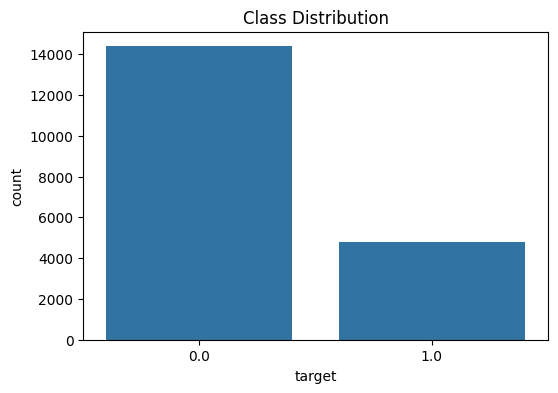

In [83]:
df=pd.read_csv("data_science_job.csv")
print(df.head())
print(df.isnull().sum())
target="target"
plt.figure(figsize=(6,4))
sns.countplot(x=target,data=df)
plt.title("Class Distribution")
plt.show()

In [ ]:
x=df.drop(target ,axis=1)
y=df[target]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)



In [ ]:
for col in X_train.columns:
    if X_train[col].dtype == 'object':
        mode_val = X_train[col].mode()[0] # Learn mode from training data
        X_train[col] = X_train[col].fillna(mode_val)
        X_test[col] = X_test[col].fillna(mode_val) # Apply same mode to test data
    else:
        median_val = X_train[col].median() # Learn median from training data
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val) # Apply same median to test data

In [80]:
for col in x_train.columns:
    if x_train[col].dtypes=="object":
        x_train[col]=x_train[col].fillna(x_train[col].mode()[0])
        x_test[col]=x_test[col].fillna(x_test[col].mode()[0])
    else:
        x_train[col]=x_train[col].fillna(x_train[col].median())
        x_test[col]=x_test[col].fillna(x_test[col].median())

In [72]:
X_train_encoded=pd.get_dummies(x_train)
X_test_encoded=pd.get_dummies(x_test)
X_train_final,X_test_final=X_train_encoded.align(X_test_encoded,axis=1,fill_value=0,join="left")

In [81]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train_final)
X_test_scaled=scaler.transform(X_test_final)

model=LogisticRegression()
model.fit(X_train_scaled, y_train)
print("✅ Model training complete!")


# === 7. EVALUATE THE MODEL ===
y_pred = model.predict(X_test_scaled)

print("accuracy",accuracy_score(y_test,y_pred))
print("recall",recall_score(y_pred,y_test))
print("confusion_matrix",confusion_matrix(y_pred,y_test))
print("classification_report",classification_report(y_pred,y_test))

✅ Model training complete!
accuracy 0.7750521920668059
recall 0.5889101338432122
confusion_matrix [[2662  647]
 [ 215  308]]
classification_report               precision    recall  f1-score   support

         0.0       0.93      0.80      0.86      3309
         1.0       0.32      0.59      0.42       523

    accuracy                           0.78      3832
   macro avg       0.62      0.70      0.64      3832
weighted avg       0.84      0.78      0.80      3832

